# 1: XGBoost and SHAP for predicting use of thrombolysis

## Plain English summary
This notebook creates three important outputs. It first creates a model for predicting use of thrombolysis in SSNAP data. Then it creates a SHAP explainer that describes how the different features of the patient data influence the model's decision to thrombolyse. Lastly, it creates a list of the SHAP values from individual stroke teams and so ranks the stroke teams that are most likely to give thrombolysis.

This model is used in the thrombolysis decisions app to predict thrombolysis use.

![Flowchart of the process to select data and create the thrombolysis prediction model and the SHAP explainer model, and to use them to rank how likely hospitals are to give thrombolysis.](images/flowchart_xgboost_shap_benchmark_teams.png)

This model use 10 features:

* stroke_team_id
* stroke_severity
* prior_disability
* age
* infarction
* onset_to_arrival_time
* precise_onset_known
* onset_during_sleep
* arrival_to_scan_time
* afib_anticoagulant

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import pickle

from dataclasses import dataclass

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
import sys
sys.path.append('../../')  # path to dir containing stroke_utilities
import stroke_utilities.process_data as process_data

## Set up paths and filenames

In [3]:
@dataclass(frozen=True)
class Paths:
    '''Singleton object for storing paths to data and database.'''

    data_read_path: str = '../../stroke_utilities/data/'
    output_folder = '../../stroke_utilities/output/'
    model_folder = '../../stroke_utilities/models/'
    model_text = 'lgbm_decision_'
    notebook: str = '01_'

paths = Paths()

## Load data

SHAP models:

In [4]:
import platform
print(platform.python_version())

3.12.11


In [5]:
shap.__version__

'0.43.0'

In [6]:
import xgboost
xgboost.__version__

'2.0.2'

In [8]:
with open(f'{paths.model_folder}/shap_explainer_resave.p', 'rb') as fp:
    explainer = pickle.load(fp)

In [9]:
with open(f'{paths.model_folder}/shap_explainer_probability_resave.p', 'rb') as fp:
    explainer_prob = pickle.load(fp)

Import the patient data from file:

In [10]:
# Load data
train = pd.read_csv(paths.data_read_path + 'cohort_10000_train.csv')
train['stroke_team_id'] = train['stroke_team_id'].astype('category')
test = pd.read_csv(paths.data_read_path + 'cohort_10000_test.csv')
test['stroke_team_id'] = test['stroke_team_id'].astype('category')

## Process data

Restrict the data to the following ten features, plus the "thrombolysis" feature.

In [11]:
# Put data into the format for model
features_to_model = [
    'stroke_team_id',
    'stroke_severity',
    'prior_disability',
    'age',
    'infarction',
    'onset_to_arrival_time',
    'precise_onset_known',
    'onset_during_sleep',
    'arrival_to_scan_time',
    'afib_anticoagulant',
    # 'year',    
    'thrombolysis'
]

In [12]:
train = train[features_to_model]
test = test[features_to_model]

In [13]:
train['stroke_team_id'].value_counts().sort_values()

stroke_team_id
85       87
95      106
109     198
102     209
63      280
       ... 
99     1544
71     1548
70     1579
6      1699
48     1756
Name: count, Length: 119, dtype: int64

If the year of admission to stroke team is still in the data, restrict it to the following range.

Currently this process does nothing because we have already removed "year" from the data.

In [14]:
# train = process_data.restrict_data_to_range(train, 2016, 2018, 'year')
# test = process_data.restrict_data_to_range(test, 2016, 2018, 'year')

Split the data. X contains the features for the model to use to predict use of thrombolysis, and y contains whether thrombolysis was used in the real data.

In [15]:
X_train, y_train = process_data.split_X_and_y(train, 'thrombolysis')
X_test, y_test = process_data.split_X_and_y(test, 'thrombolysis')

For the XGBoost model, we need to change the single "stroke team ID" column to many individual team columns. For 119 separate teams, we will create 119 new columns. Each column may contain either 1 (meaning "yes") where a patient attended that stroke team, or 0 (meaning "no") where the patient did not attend that stroke team.

In [16]:
X_train = process_data.one_hot_encode_column(
    X_train, 'stroke_team_id', prefix='team')

X_test = process_data.one_hot_encode_column(
    X_test, 'stroke_team_id', prefix='team')

Check that the "stroke_team_id" column has gone and that there are now many "team_" columns.

In [17]:
# Get features
features_ohe = list(X_train)

# Print the first several...
print(features_ohe[:15])
# ... and last few feature names:
print(features_ohe[-3:])
# The remaining features are all "team_X" for increasing X.

['stroke_severity', 'prior_disability', 'age', 'infarction', 'onset_to_arrival_time', 'precise_onset_known', 'onset_during_sleep', 'arrival_to_scan_time', 'afib_anticoagulant', 'team_1', 'team_2', 'team_3', 'team_4', 'team_5', 'team_6']
['team_117', 'team_118', 'team_119']


In [18]:
team_cols = [c for c in X_train.columns if c.startswith('team_')]
X_train[team_cols] = X_train[team_cols].astype(int)
X_test[team_cols] = X_test[team_cols].astype(int)

## Create SHAP values for the test data: probability units

Pass the X_test data to the probability explainer object:

In [19]:
shap_values_extended_prob = explainer_prob(X_test)
shap_values_prob = explainer_prob.shap_values(X_test)

 93%|=================== | 9347/10000 [00:11<00:00]       

Check the results for the first patient in the data. The results contain `.values`, the SHAP value for each feature for this patient. There is also `.base_values`, the probability that all patients start at before the model adjusts the probability based on the feature values. Finally there is `.data`, which is the original data for this patient that was used to create the prediction.

The other data we created, `shap_values_prob`, contains only the `.values` data from the `shap_values_extended_prob` so is generally easier to use.

In [20]:
shap_values_extended_prob[0]

.values =
array([ 3.87886533e-02,  3.70862884e-02, -3.46092413e-03,  1.37325274e-02,
        1.18373312e-02,  3.03868357e-02,  0.00000000e+00,  4.26785970e-02,
       -4.04243140e-01,  5.26333389e-04,  0.00000000e+00,  1.01114822e-03,
        5.32800721e-03,  2.27885895e-04,  4.43104733e-04, -8.47494541e-04,
        0.00000000e+00, -1.80935741e-04,  1.74747094e-05, -1.13455096e-03,
        0.00000000e+00, -1.36780143e-03,  0.00000000e+00,  9.76897700e-04,
        3.56446304e-04,  0.00000000e+00, -3.49813615e-04,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  2.05995293e-02, -9.17906007e-04,
        0.00000000e+00,  3.71677653e-04,  2.94691277e-03,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.26372553e-04,  0.00000000e+00,
        2.00551079e-04,  5.09538418e-04,  0.00000000e+00,  0.00000000e+00,
       -1.55490525e-05,  5.31152152e-05,  0.00000000e+00,  0.00000000e+00,
       -9.28802391e-05, -6.15417993e-04,  0.00000000e+00, -8.57386956e-05,
        2.39998

The `base_values` probability is the same for all patients and is used in the stroke predictions streamlit app when describing how the model works.

In [21]:
# Check the base values for a few patients:
for i in range(5):
    print(shap_values_extended_prob[i].base_values)

0.39262291495992435
0.39262291495992435
0.39262291495992435
0.39262291495992435
0.39262291495992435


## Create SHAP values for the test data: log-odds units

Pass the X_test data to the explainer object:

In [22]:
shap_values_extended = explainer(X_test)
shap_values = explainer.shap_values(X_test)

The contents of these arrays is identical to those for probability, just in different units.

## Get stroke team SHAP: method 2

These SHAP values are calculated using a different subset of data for each stroke team. Each stroke team's SHAP value here is calculated only from patients that attended that stroke team. Patients who did not attend that stroke team go unused in that calculation.

In [23]:
# Set up list for storing patient data and hospital SHAP
feature_data_with_shap = []

# Get mean SHAP for stroke team when patient attending that stroke team
unique_stroketeams_list = list(np.unique(test['stroke_team_id']))
stroke_team_mean_shap = []
# Loop through stroke teams
for stroke_team in unique_stroketeams_list:
    # Identify rows in test data that match each stroke team
    mask = test['stroke_team_id'] == stroke_team
    stroke_team_shap_all_features = shap_values[mask]
    # Get column index for stroke_team_in_shap
    feature_name = f'team_{stroke_team}'
    index = features_ohe.index(feature_name)
    # Get SHAP values for hospital
    stroke_team_shap = stroke_team_shap_all_features[:, index]
    # Get mean
    mean_shap = np.mean(stroke_team_shap)
    # Store mean
    stroke_team_mean_shap.append(mean_shap)
    # Get and store feature data and add SHAP
    feature_data = X_test[mask]
    feature_data['Hospital_SHAP'] = stroke_team_shap
    feature_data_with_shap.append(feature_data)

# Concatenate and save feature_data_with_shap
feature_data_with_shap = pd.concat(feature_data_with_shap, axis=0)
# feature_data_with_shap.to_csv(
#    f'./predictions/{notebook}_{model_text}_feature_data_with_hospital_shap.csv', 
#     index=False)

# Create and save shap mean value per hospital
hospital_data = pd.DataFrame()
hospital_data["stroke_team_id"] = unique_stroketeams_list
hospital_data["shap_mean"] = stroke_team_mean_shap
# hospital_data.to_csv(
#     f'./predictions/{notebook}_{model_text}_mean_shap_per_hospital.csv', 
#     index=False)

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/ind

The result:

In [24]:
hospital_data

,stroke_team_id,shap_mean
0,1,-0.170769
1,2,0.573549
2,3,-0.201626
3,4,-1.233141
4,5,-0.197647
...,...,...
114,115,0.848567
115,116,0.445670
116,117,-0.688748
117,118,0.667060


Quick look at the spread of SHAP values:

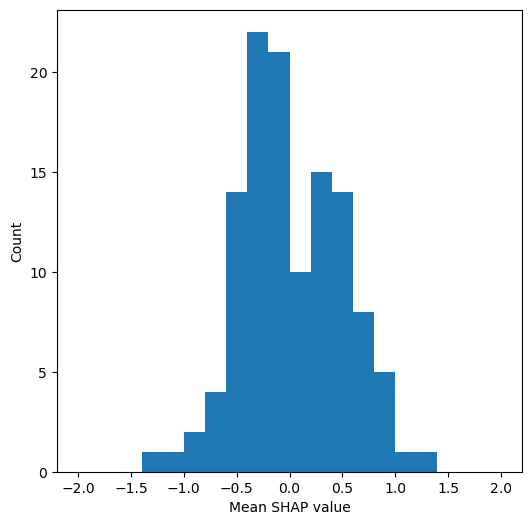

In [25]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot()
ax.hist(hospital_data['shap_mean'], bins=np.arange(-2.0, 2.01, 0.2))
ax.set_xlabel('Mean SHAP value')
ax.set_ylabel('Count')

plt.show()

In [26]:
mean_shap = np.mean(hospital_data['shap_mean'])
std_shap = np.std(hospital_data['shap_mean'])
print(f'Mean hospital SHAP: {mean_shap:0.3f}')
print(f'Mean hospital SHAP STDdev: {std_shap:0.3f}')

Mean hospital SHAP: 0.024
Mean hospital SHAP STDdev: 0.478


## Extract benchmark ranking

Sort the above DataFrame with higher mean SHAP values nearer the top. Add a column to show the rank of the team.

In [27]:
hospital_data = hospital_data.sort_values('shap_mean', ascending=False)
hospital_data['Rank'] = np.arange(1, len(hospital_data) + 1)

hospital_data

,stroke_team_id,shap_mean,Rank
101,102,1.341623,1
71,72,1.111925,2
7,8,0.997945,3
70,71,0.949360,4
36,37,0.905034,5
...,...,...,...
116,117,-0.688748,115
57,58,-0.820926,116
64,65,-0.832516,117
25,26,-1.062729,118


Save this dataframe to file:

In [28]:
hospital_data.to_csv(f'{paths.output_folder}/benchmark_codes_resave.csv', index=False)
hospital_data.to_csv('benchmark_codes.csv', index=False)

Pull out the top 25 values. These are the benchmark teams.

In [29]:
benchmark_team_id_list = hospital_data['stroke_team_id'].values[:25]

benchmark_team_id_list

array([102,  72,   8,  71,  37,  57, 115,  48,  21,  80, 104,  83, 118,
        98,  64,  19,   2, 103,  97,  63,  95,  13,  31, 101,  34])